In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Generating the data

In [2]:
df = pd.DataFrame({"Age":[36, 42, 23, 52, 43, 44, 66, 35, 52, 35, 24, 18, 45]
,"Experience":[10, 12, 4, 4, 21, 14, 3, 14, 13, 5, 3, 3, 9]
,"Health Condition":[9,4,6,4,8,5,7,9,7,9,5,7,9]
,"Selected":['NO','NO', 'NO', 'NO', 'YES','NO', 'YES', 'YES', 'YES', 'YES','NO', 'YES', 'YES']})

df

,Age,Experience,Health Condition,Selected
0,36,10,9,NO
1,42,12,4,NO
2,23,4,6,NO
3,52,4,4,NO
4,43,21,8,YES
5,44,14,5,NO
6,66,3,7,YES
7,35,14,9,YES
8,52,13,7,YES
9,35,5,9,YES


# Transforming Strings into Integers

In [3]:
d = {'YES': 1, 'NO': 0}
df['Selected'] = df['Selected'].map(d)

print(df)

    Age  Experience  Health Condition  Selected
0    36          10                 9         0
1    42          12                 4         0
2    23           4                 6         0
3    52           4                 4         0
4    43          21                 8         1
5    44          14                 5         0
6    66           3                 7         1
7    35          14                 9         1
8    52          13                 7         1
9    35           5                 9         1
10   24           3                 5         0
11   18           3                 7         1
12   45           9                 9         1


# Extracting Features and Labels

In [4]:
features = ['Age', 'Experience', 'Health Condition']

X = df[features]
y = df['Selected']

In [5]:
X

,Age,Experience,Health Condition
0,36,10,9
1,42,12,4
2,23,4,6
3,52,4,4
4,43,21,8
5,44,14,5
6,66,3,7
7,35,14,9
8,52,13,7
9,35,5,9


In [6]:
y

,Selected
0,0
1,0
2,0
3,0
4,1
5,0
6,1
7,1
8,1
9,1


# Instantiating Decision Tree Classifier and fitting to the data

In [7]:
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

# Visualizing Decision Tree

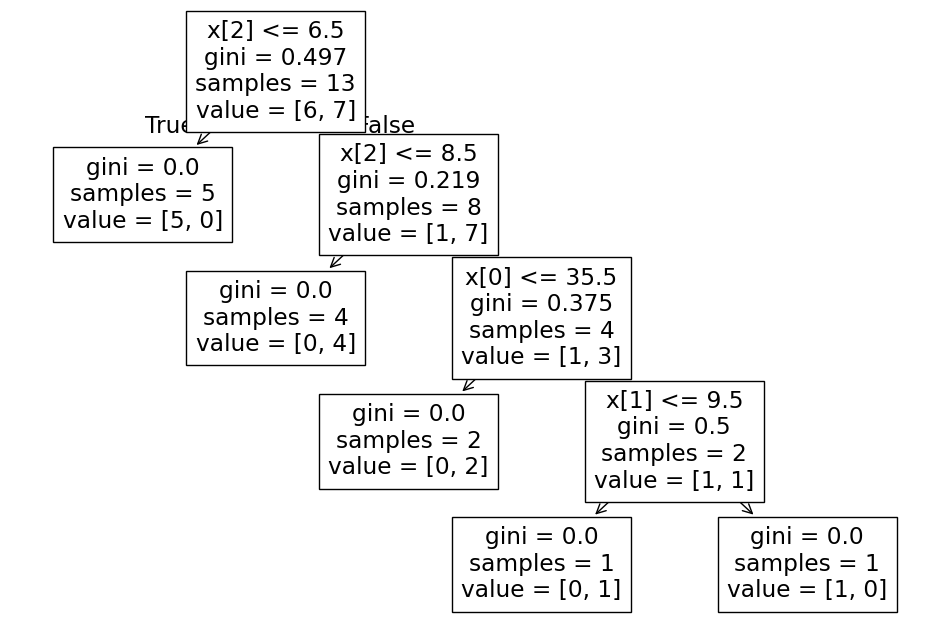

In [8]:
plt.figure(figsize=(12,8))
plot_tree(dtree);

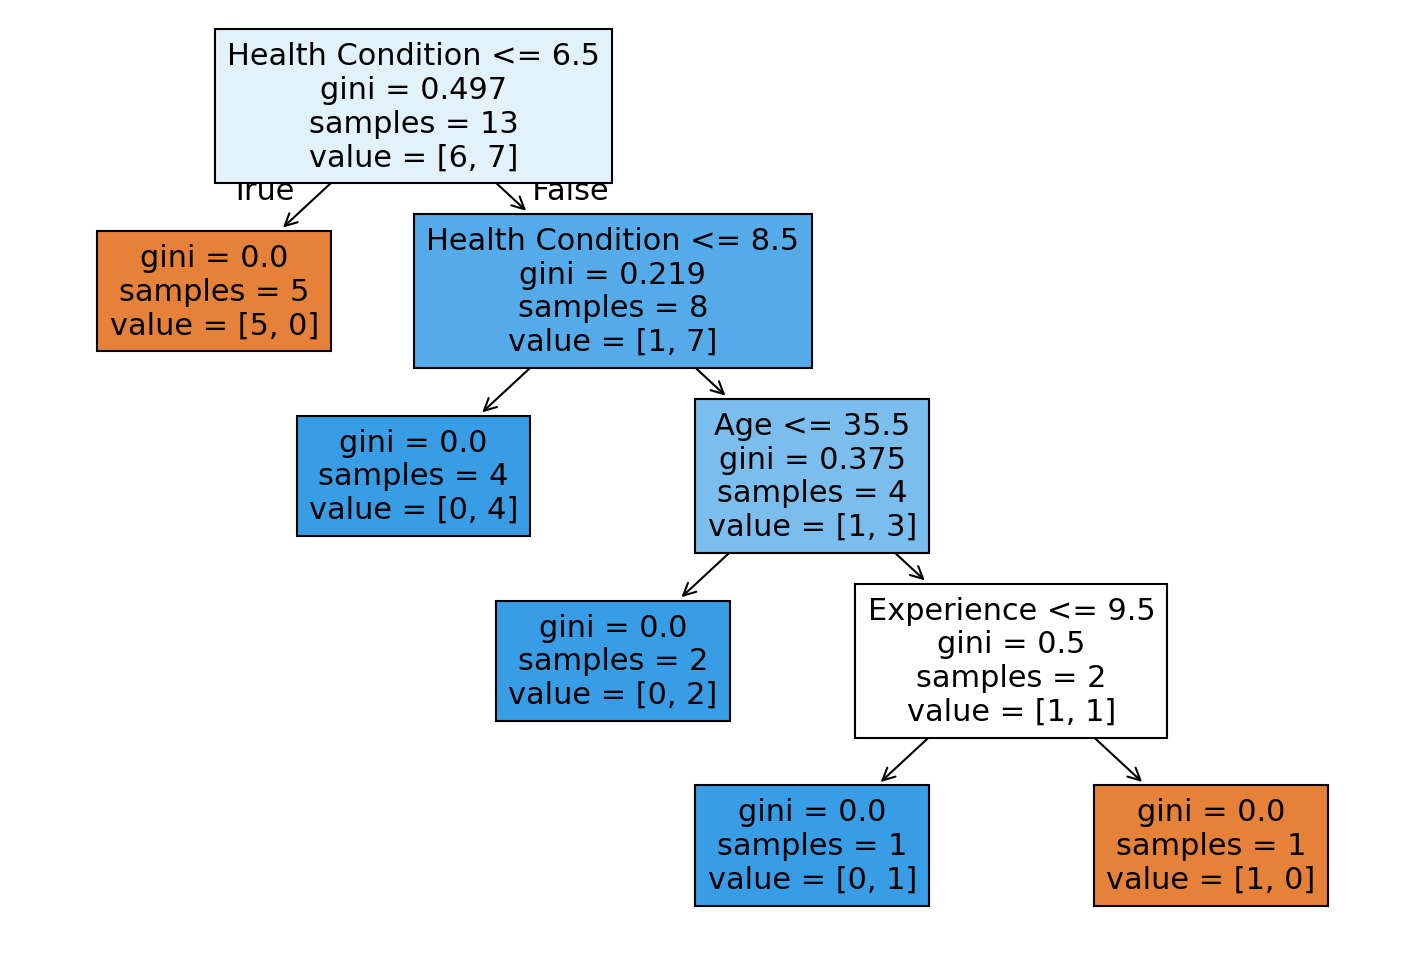

In [9]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(dtree, filled = True, feature_names = X.columns);

# Getting important features

In [10]:
pd.DataFrame(index = X.columns, data=dtree.feature_importances_, columns=['Feature Importance'])

,Feature Importance
Age,0.077381
Experience,0.154762
Health Condition,0.767857


# Generating Test data and getting predictions fromm tree classifier

In [11]:
X_test = pd.DataFrame({"Age":[40],"Experience":[11], "Health Condition":[6]})
X_test

,Age,Experience,Health Condition
0,40,11,6


In [12]:
print(dtree.predict(X_test))

[0]


In [13]:
X_test_02 = pd.DataFrame({"Age":[70],"Experience":[21], "Health Condition":[9]})
X_test_02

,Age,Experience,Health Condition
0,70,21,9


In [14]:
print(dtree.predict(X_test_02))

[0]


# Creating tree model using criterion ='entropy'

In [15]:
entropy_tree = DecisionTreeClassifier(criterion='entropy')
entropy_tree.fit(X,y)

DecisionTreeClassifier(criterion='entropy')

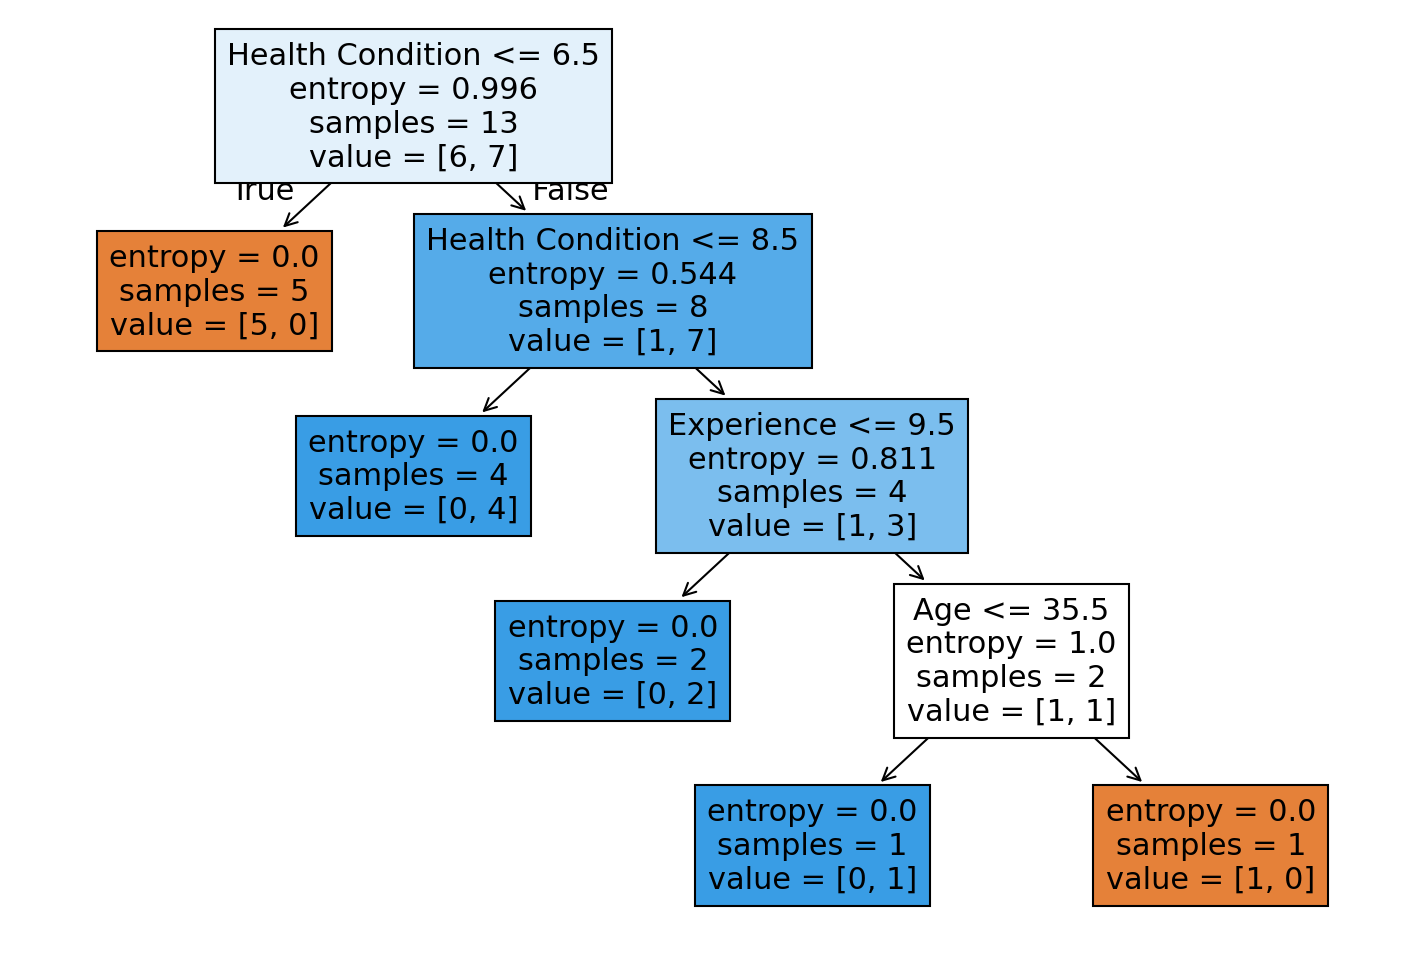

In [16]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(entropy_tree,filled=True,feature_names=X.columns);

In [17]:
pd.DataFrame(index=X.columns,data=entropy_tree.feature_importances_,columns=['Feature Importance'])

,Feature Importance
Age,0.154506
Experience,0.096189
Health Condition,0.749305


In [18]:
print(dtree.predict(X_test))

[0]


In [19]:
print(dtree.predict(X_test_02))

[0]
